##### Trendfolge 200d rolling avg


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path
from matplotlib.ticker import PercentFormatter

from backtest import kennzahlen, backtest


In [ ]:
if Path("data/spy.csv").exists():
    print("file already exists")
else:
    spy = yf.download("SPY", start="1993-01-01", auto_adjust=True, multi_level_index=False)
    spy.to_csv("./data/spy.csv")

data = pd.read_csv("./data/spy.csv", index_col=0, parse_dates=True)
data.head(5)

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
1993-01-29,24.053524,24.070632,23.950877,24.070632,1003200
1993-02-01,24.224598,24.224598,24.070628,24.070628,480500
1993-02-02,24.275936,24.293044,24.156182,24.207505,201300
1993-02-03,24.532541,24.549649,24.293033,24.310140,529400
1993-02-04,24.635201,24.686524,24.344368,24.618093,531500


check for duplicates

In [5]:
print(f"First available date: {data.index[0].date()}")
print(f"Last available date: {data.index[-1].date()}")
print(f"Number of trading days: {len(data)}")

print(f"Number of duplicates: {data.index.duplicated().sum()}")
print(f"Sorted by date: {data.index.is_monotonic_increasing}")

First available date: 1993-01-29
Last available date: 2026-10-09
Number of trading days: 8482
Number of duplicates: 0
Sorted by date: True


#### Plot closing price lin and log

<Axes: title={'center': 'SPY, logarithmic axis'}, xlabel='Date'>

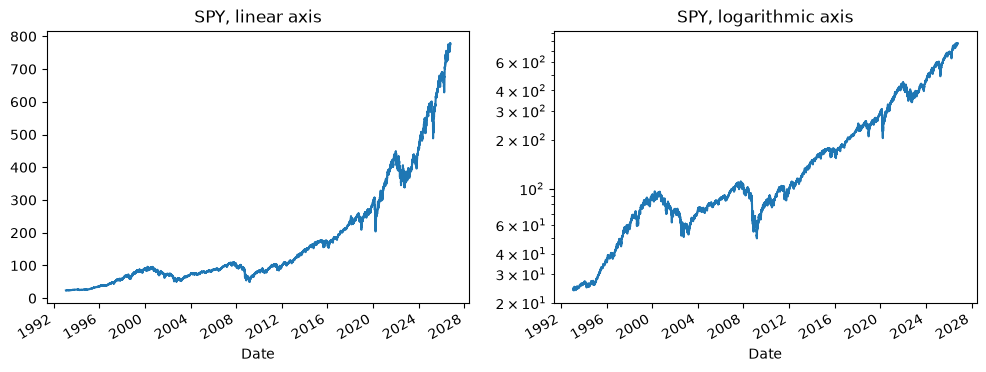

In [6]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

data["Close"].plot(ax=ax1, title="SPY, linear axis")
data["Close"].plot(ax=ax2, title="SPY, logarithmic axis", logy=True)

In [7]:
data["Rendite"] = data["Close"].pct_change().fillna(0)
data["wert_bh"] = (1 + data["Rendite"]).cumprod()
data.tail(10)

,Close,High,Low,Open,Volume,Rendite,wert_bh
Date,,,,,,,
2026-09-28,765.609985,769.539978,763.719971,768.349976,42694500,-0.007441,31.829431
2026-09-29,764.200012,766.979980,762.349976,766.830017,36910500,-0.001842,31.770813
2026-09-30,762.630005,769.409973,762.179993,766.450012,62110000,-0.002054,31.705542
2026-10-01,763.989990,765.650024,758.789978,764.359985,47708100,0.001783,31.762082
2026-10-02,769.640015,772.650024,767.150024,770.580017,46335300,0.007395,31.996975
2026-10-05,774.830017,776.609985,769.630005,769.690002,44840200,0.006743,32.212744
2026-10-06,779.090027,781.619995,777.960022,778.150024,36054300,0.005498,32.389850
2026-10-07,777.219971,779.099976,773.609985,775.770020,30989200,-0.002400,32.312104
2026-10-08,773.929993,777.090027,770.440002,774.859985,40351800,-0.004233,32.175327


In [8]:
## check if both values are equal 

print(data["wert_bh"].iloc[-1])
print(data["Close"].iloc[-1] / data["Close"].iloc[0])

# get 5 days with largest gains and losses
print(f"5 Tage mit größtem Gewinn: {data["Rendite"].nlargest(5)}")
print(f"5 Tage mit größtem Verlust: {data["Rendite"].nsmallest(5)}")



32.32915078565714
32.329150785657
5 Tage mit größtem Gewinn: Date
2008-10-13    0.145198
2008-10-28    0.116855
2025-04-09    0.105019
2020-03-24    0.090603
2020-03-13    0.085486
Name: Rendite, dtype: float64
5 Tage mit größtem Verlust: Date
2020-03-16   -0.109424
2008-10-15   -0.098448
2020-03-12   -0.095677
2008-12-01   -0.088578
2008-09-29   -0.078361
Name: Rendite, dtype: float64


In [9]:
# simple moving average (SMA)
TIMEFRAME = 200
data["sma"] = data["Close"].rolling(window=TIMEFRAME).mean()
data["Signal"] = np.where(data["Close"] > data["sma"], 1.0, 0.0)
data["Signal"] = data["Signal"].where(data["sma"].notna())
data["Position"] = data["Signal"].shift(1)

print(f"Anteil Tage investiert: {data['Position'].mean():.1%}")


Anteil Tage investiert: 77.4%


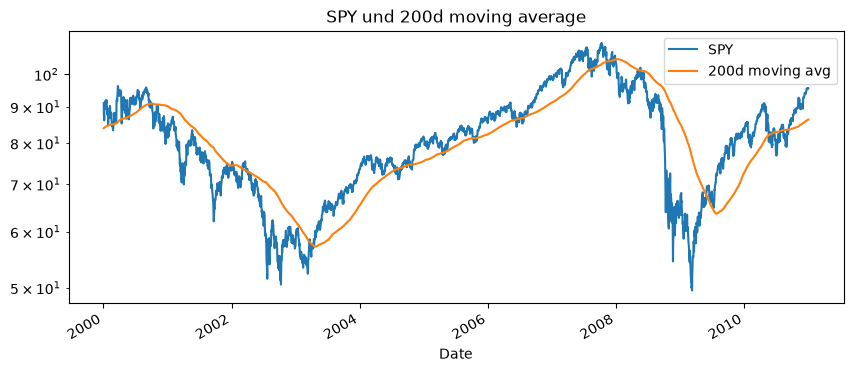

In [10]:
ax = data.loc["2000":"2010", ["Close", "sma"]].plot(logy=True, figsize=(10,4), title="SPY und 200d moving average")
ax.legend(["SPY", "200d moving avg"])
plt.show()

In [11]:
bt = data[["Rendite", "Position"]].dropna().copy()
bt["Wechsel"] = bt["Position"].diff().abs().fillna(bt["Position"].iloc[0])
KOSTEN = 0.001
bt["Strategie"] = bt["Position"] * bt["Rendite"] - bt["Wechsel"] * KOSTEN
bt["Buy_Hold"] = bt["Rendite"]
bt.tail()

,Rendite,Position,Wechsel,Strategie,Buy_Hold
Date,,,,,
2026-10-05,0.006743,1.0,0.0,0.006743,0.006743
2026-10-06,0.005498,1.0,0.0,0.005498,0.005498
2026-10-07,-0.002400,1.0,0.0,-0.002400,-0.002400
2026-10-08,-0.004233,1.0,0.0,-0.004233,-0.004233
2026-10-09,0.004781,1.0,0.0,0.004781,0.004781


In [12]:
#gesamtanzahl der Jahre 
jahre = (bt.index[-1] - bt.index[0]).days / 365.25

print(f"Zeitraum: {bt.index[0].date()} bis {bt.index[-1].date()} ({jahre:.1f} Jahre)")
print(f"Wechsel insgesamt: {bt['Wechsel'].sum():.0f}")
print(f"Wechsel pro Jahr: {bt['Wechsel'].sum() / jahre:.1f}")
print(f"Summe der Kosten: {(bt['Wechsel'] * KOSTEN).sum():.2%}")

Zeitraum: 1993-11-12 bis 2026-10-09 (32.9 Jahre)
Wechsel insgesamt: 215
Wechsel pro Jahr: 6.5
Summe der Kosten: 21.50%


<Axes: title={'center': 'Wert von 1 USD nach Kosten bei Strategie und Buy&Hold'}, xlabel='Date'>

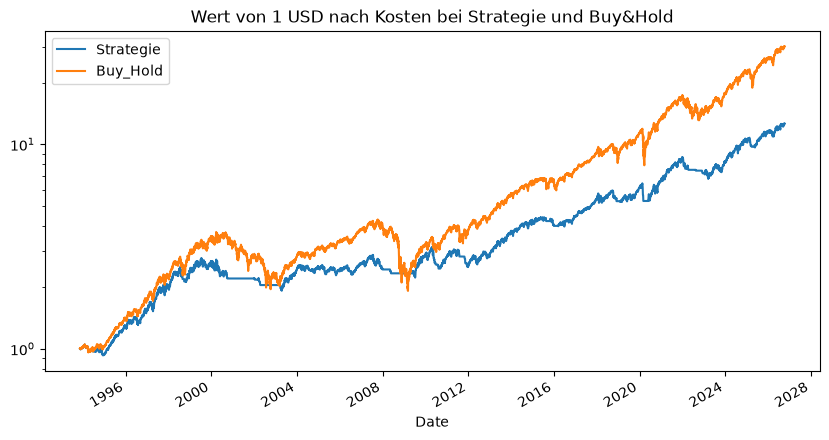

In [17]:
(1+bt[["Strategie", "Buy_Hold"]]).cumprod().plot(logy=True, figsize=(10,5), title="Wert von 1 USD nach Kosten bei Strategie und Buy&Hold")

#### Kennzahlen

In [14]:


tabelle = bt[["Strategie", "Buy_Hold"]].apply(kennzahlen)
print(tabelle.round(3))


                   Strategie  Buy_Hold
Rendite p. a.          0.080     0.109
Volatilität p. a.      0.121     0.187
Sharpe Ratio           0.697     0.648
Max. Drawdown         -0.308    -0.552


### Ergebnisse visualisieren

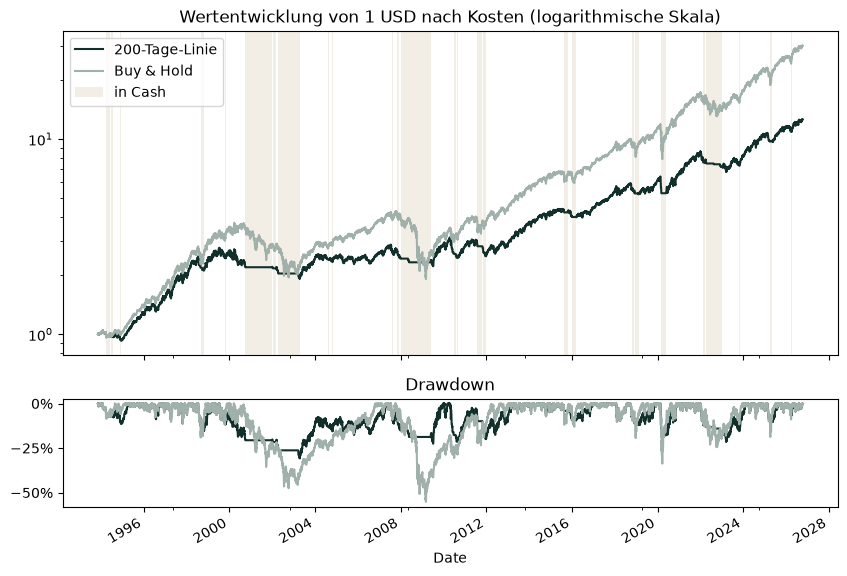

In [15]:

FARBEN = ["#12302b", "#9fb1aa"]    

wert = (1 + bt[["Strategie", "Buy_Hold"]]).cumprod()
wert.columns = ["200-Tage-Linie", "Buy & Hold"]
drawdown = wert / wert.cummax().clip(lower=1) - 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

wert.plot(ax=ax1, logy=True, color=FARBEN)
ax1.fill_between(bt.index, 0, 1, where=bt["Position"] == 0,
                 transform=ax1.get_xaxis_transform(),
                 color="#b39256", alpha=0.15, linewidth=0, label="in Cash")
ax1.set_title("Wertentwicklung von 1 USD nach Kosten (logarithmische Skala)")
ax1.legend()

# 4. Unten: Drawdown in Prozent
drawdown.plot(ax=ax2, color=FARBEN, legend=False)
ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.set_title("Drawdown")


fig.savefig("../../docs/img/01-trendfolge.png", dpi=150, bbox_inches="tight")

### Backtest


In [16]:
fenster = [50, 100, 150, 200, 250, 300, 500, 1000]
laeufe = {w: backtest(data["Close"], window=w) for w in fenster}
start = max(e.index[0] for e in laeufe.values())      # gemeinsamer Start für alle

ergebnisse = {}
for w, e in laeufe.items():
    e = e.loc[start:]
    k = kennzahlen(e["Strategie"])
    k["Wechsel pro Jahr"] = e["Wechsel"].sum() / ((e.index[-1] - e.index[0]).days / 365.25)
    ergebnisse[w] = k
ergebnisse["Buy & Hold"] = kennzahlen(laeufe[200].loc[start:, "Buy_Hold"])

print(f"Gemeinsamer Start: {start.date()}")
print(pd.DataFrame(ergebnisse).T.round(3))

Gemeinsamer Start: 1997-01-14
            Max. Drawdown  Rendite p. a.  Sharpe Ratio  Volatilität p. a.  \
50                 -0.519          0.023         0.262              0.112   
100                -0.545          0.050         0.472              0.117   
150                -0.382          0.059         0.540              0.121   
200                -0.308          0.072         0.631              0.123   
250                -0.250          0.073         0.622              0.127   
300                -0.234          0.092         0.741              0.131   
500                -0.351          0.065         0.516              0.141   
1000               -0.393          0.078         0.568              0.154   
Buy & Hold         -0.552          0.100         0.590              0.193   

            Wechsel pro Jahr  
50                    17.825  
100                   11.031  
150                    9.215  
200                    6.525  
250                    5.381  
300          